# Inference demo & ONNX export



In [2]:
import subprocess, sys, os, warnings
warnings.filterwarnings("ignore")

MARKER = "/kaggle/working/.cell0_pytorch_ready"  

def install_t4_pytorch():
    subprocess.check_call([
        sys.executable, "-m", "pip", "install","torch==2.5.1", "torchvision==0.20.1","--index-url", "https://download.pytorch.org/whl/cu124","-q", "--force-reinstall",])

def cuda_smoke():
    import torch
    if not torch.cuda.is_available():
        return False
    try:
        t = torch.tensor([0, 1, -100], device="cuda")
        return int((t.ne(-100)).sum().item()) == 2
    except Exception:
        return False

if not os.path.isfile(MARKER):
    import torch
    print("GPU check")
    print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
    print("PyTorch:", torch.__version__)
    if cuda_smoke():
        print("CUDA: OK")
        open(MARKER, "w").write("ok")
    else:
        print
        install_t4_pytorch()
        open(MARKER, "w").write("restart")
        raise SystemExit

import torch
import torchvision
if not cuda_smoke():
    if os.path.isfile(MARKER):
        os.remove(MARKER)
    raise RuntimeError

print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("CUDA: OK")

try:
    import fsspec
    fsspec_ver = fsspec.__version__
except ImportError:
    fsspec_ver = None

with open("/kaggle/working/pip-constraints.txt", "w") as f:
    f.write("torch==" + torch.__version__ + "\n")
    f.write("torchvision==" + torchvision.__version__ + "\n")
    if fsspec_ver:
        f.write("fsspec==" + fsspec_ver + "\n")

print("Done")


GPU check
GPU: Tesla T4
PyTorch: 2.10.0+cu128
CUDA: OK
GPU: Tesla T4
PyTorch: 2.10.0+cu128
CUDA: OK
Done


In [3]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
from torchvision import transforms
from transformers import DeiTForImageClassificationWithTeacher, DeiTImageProcessor


WORKING_CONFIG = "/kaggle/working/config.json"
DATA_PREP_INPUT = "/kaggle/input/datasets/nikachuu/data-prep"

def load_config():
    import glob
    candidates = [WORKING_CONFIG]
    input_cfg = os.path.join(DATA_PREP_INPUT, "config.json")
    if os.path.isfile(input_cfg):
        candidates.append(input_cfg)
    for p in sorted(glob.glob("/kaggle/input/**/config.json", recursive=True)):
        if p not in candidates:
            candidates.append(p)
    config_path = next((p for p in candidates if os.path.isfile(p)), None)
    if not config_path:
        raise 
    with open(config_path) as f:
        config = json.load(f)
    roots = [
        config.get("dataset_path"),
        os.path.join(os.path.dirname(config_path), "dataset"),
        os.path.join(DATA_PREP_INPUT, "dataset"),"/kaggle/working/dataset",]
    for root in roots:
        if not root:
            continue
        train_ann = os.path.join(root, "train", "_annotations.coco.json")
        if os.path.isfile(train_ann):
            config["dataset_path"] = root
            config["train_ann"] = train_ann
            config["valid_ann"] = os.path.join(root, "valid", "_annotations.coco.json")
            config["test_ann"] = os.path.join(root, "test", "_annotations.coco.json")
            config["train_img_dir"] = os.path.join(root, "train")
            config["valid_img_dir"] = os.path.join(root, "valid")
            config["test_img_dir"] = os.path.join(root, "test")
            break
    else:
        raise FileNotFoundError
    config["save_dir"] = config.get("save_dir") or "/kaggle/working/results"
    os.makedirs(config["save_dir"], exist_ok=True)
    return config, config_path

config, CONFIG_PATH = load_config()

print("Config:", CONFIG_PATH)

Experiment_Name = config["Experiment_Name"]
deit_variant = config["deit_variant"]
Confidence_Threshold = config["Confidence_Threshold"]
save_dir = config["save_dir"]
test_img_dir = config["test_img_dir"]


def resolve_existing_path(config_key, default_name, mode="dir"):
    import glob

    candidates = []
    if config.get(config_key):
        candidates.append(config[config_key])
    candidates.append(os.path.join(save_dir, default_name))

    if mode == "dir":
        candidates.extend(glob.glob(f"/kaggle/input/**/{default_name}", recursive=True))
    else:
        candidates.extend(glob.glob(f"/kaggle/input/**/{default_name}", recursive=True))

    seen = set()
    for p in candidates:
        if not p or p in seen:
            continue
        seen.add(p)
        if mode == "dir" and os.path.isdir(p):
            return p
        if mode == "file" and os.path.isfile(p):
            return p
    return None


DEIT_SAVE = resolve_existing_path("DEIT_SAVE", "deit_best_model", mode="dir")
rcnn_save_path = resolve_existing_path("rcnn_save_path", "rcnn_best.pth", mode="file")

if not DEIT_SAVE:
    raise FileNotFoundError
if not rcnn_save_path:
    raise FileNotFoundError
print("Using DEIT_SAVE:", DEIT_SAVE)
print("Using rcnn_save_path:", rcnn_save_path)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = DeiTImageProcessor.from_pretrained(deit_variant)

from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

with open(config["train_ann"]) as f:
    coco_info = json.load(f)
NUM_CLASSES = len(coco_info["categories"]) + 1

deit_model = DeiTForImageClassificationWithTeacher.from_pretrained(DEIT_SAVE).to(DEVICE)
rcnn_model = fasterrcnn_resnet50_fpn_v2(weights=None)
in_feat = rcnn_model.roi_heads.box_predictor.cls_score.in_features
rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, NUM_CLASSES)
rcnn_model.load_state_dict(torch.load(rcnn_save_path, map_location=DEVICE))
rcnn_model.to(DEVICE)
print("Models are loaded")


Config: /kaggle/input/datasets/nikachuu/data-prep/config.json
Using DEIT_SAVE: /kaggle/input/datasets/nikachuu/det-best-model/results/deit_best_model
Using rcnn_save_path: /kaggle/input/datasets/nikachuu/rcnn-best-model/results/rcnn_best.pth


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Models are loaded


File Rhizome-Disease-Root00002_JPG.rf.1c5f34fbb1e1cafabc2ea978054a30f2.jpg
DeiT Infected 77.2 percent
R-CNN regions 1


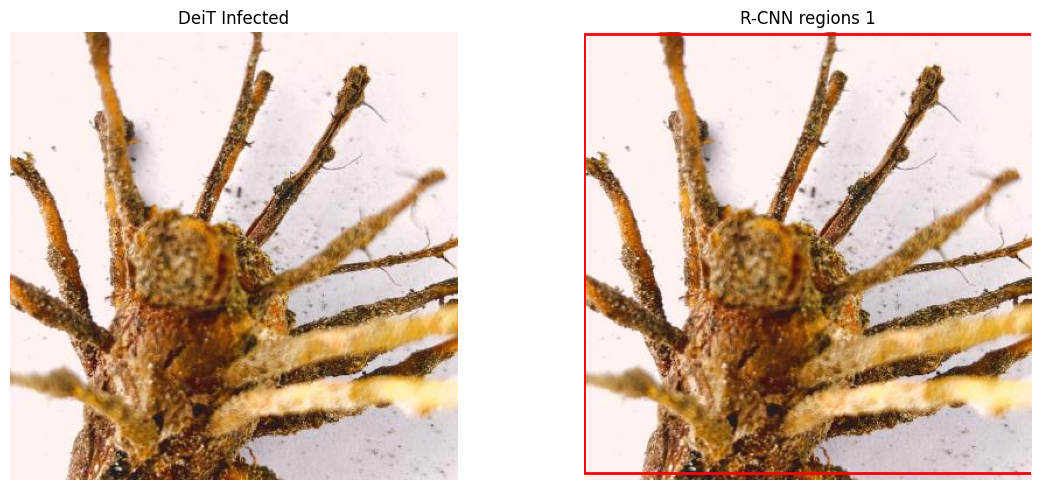

File Rhizome-Disease-Root00005_JPG.rf.237d65c1ddfd7ef65774f807d7fda034.jpg
DeiT Infected 98.3 percent
R-CNN regions 1


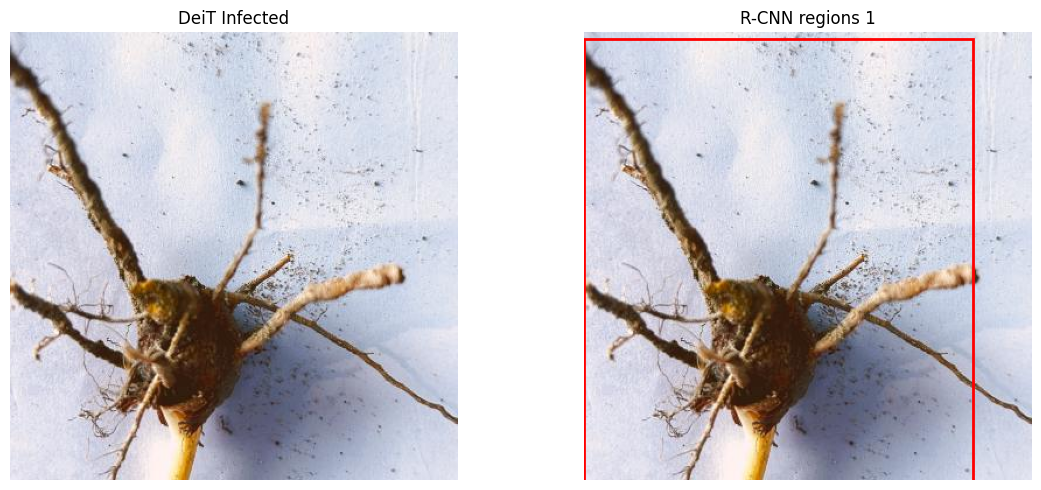

File Rhizome-Disease-Root00018_JPG.rf.51bd9625eb2add0fb3088ece2a11f44b.jpg
DeiT Infected 97.0 percent
R-CNN regions 1


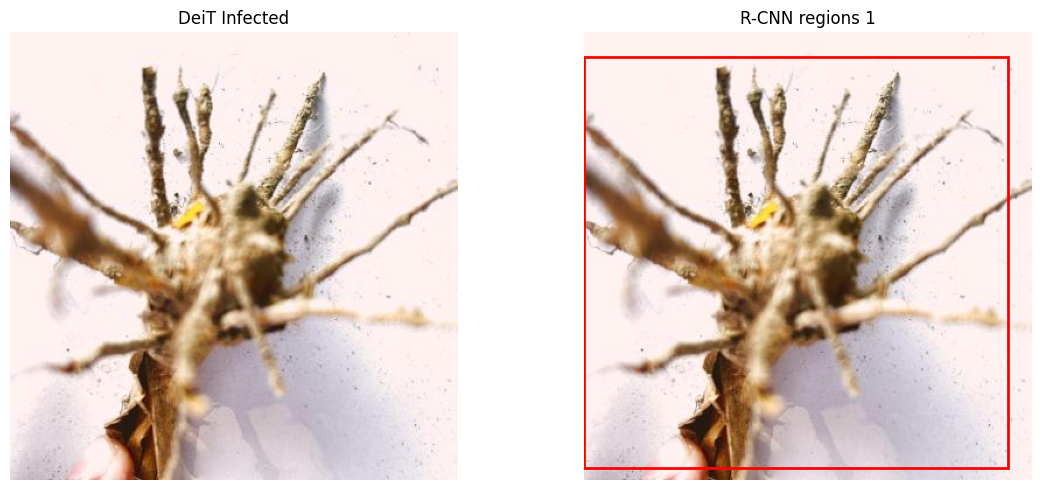

File Rhizome-Disease-Root00019_JPG.rf.bf2c6c93e58f13e51fbd18c9902aaa05.jpg
DeiT Infected 97.4 percent
R-CNN regions 1


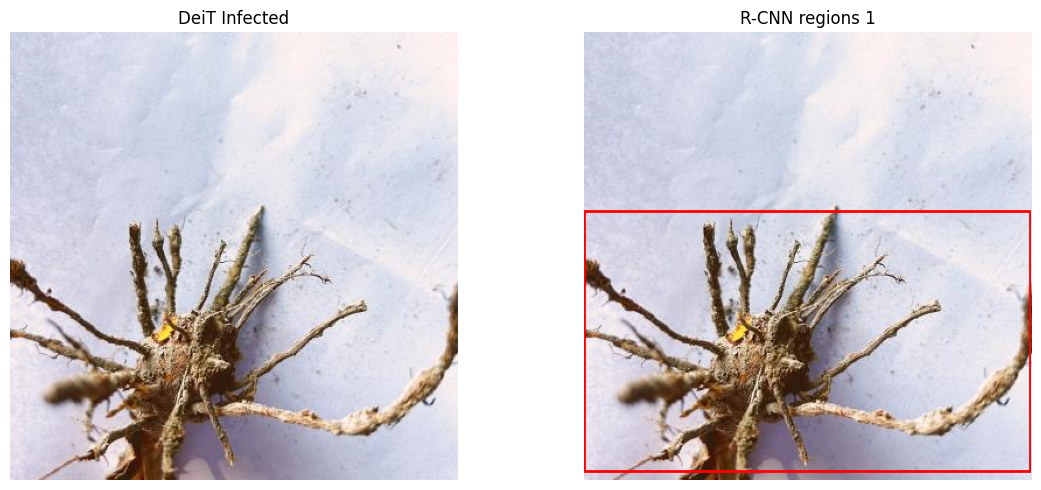

File Rhizome-Disease-Root00029_JPG.rf.767f4ca0bb6a606e706591f0840523b7.jpg
DeiT Infected 97.4 percent
R-CNN regions 2


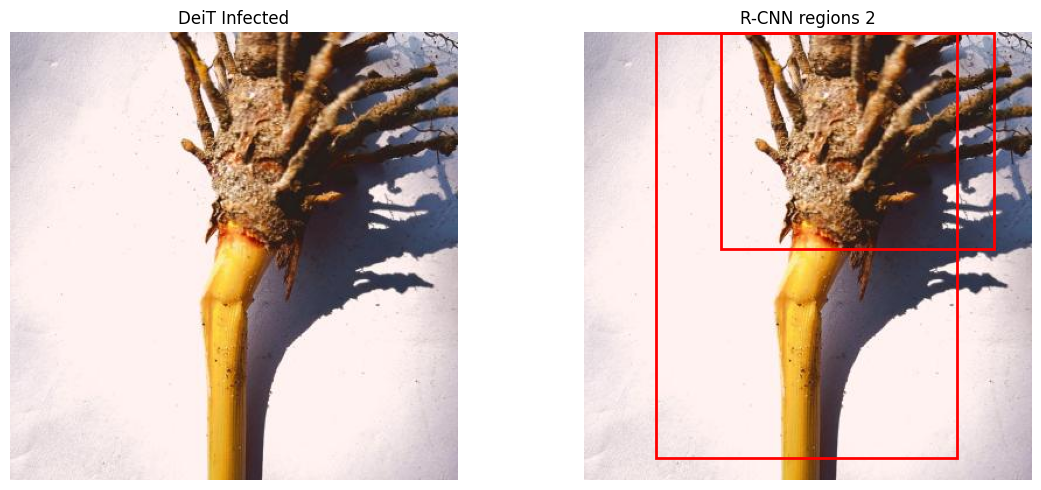

In [4]:
def predict(image_path, threshold=Confidence_Threshold, show=True):
    LABELS = {0: "Healthy", 1: "Infected"}
    img_pil = Image.open(image_path).convert("RGB")
    deit_model.eval()
    pv = processor(images=img_pil, return_tensors="pt")["pixel_values"].to(DEVICE)
    with torch.no_grad():
        out = deit_model(pixel_values=pv)
        logits = (out.cls_logits + out.distillation_logits) / 2
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        conf = probs[0, pred].item()
    print("DeiT", LABELS[pred], round(conf * 100, 1), "percent")
    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img_pil)
        axes[0].set_title("DeiT " + LABELS[pred])
        axes[0].axis("off")
        axes[1].imshow(img_pil)
        axes[1].axis("off")
        if pred == 1:
            rcnn_model.eval()
            with torch.no_grad():
                dets = rcnn_model([transforms.ToTensor()(img_pil).to(DEVICE)])[0]
            n = 0
            for box, score in zip(dets["boxes"].cpu(), dets["scores"].cpu()):
                if score >= threshold:
                    x1, y1, x2, y2 = box
                    axes[1].add_patch(patches.Rectangle(
                        (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor="red", facecolor="none"))
                    n += 1
            axes[1].set_title("R-CNN regions " + str(n))
            print("R-CNN regions", n)
        else:
            axes[1].set_title("Healthy, R-CNN skipped")
        plt.tight_layout()
        out_png = os.path.join(save_dir, "demo_" + os.path.basename(image_path))
        plt.savefig(out_png, dpi=120)
        plt.show()
    return pred, conf

test_files = sorted([f for f in os.listdir(test_img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
for fname in test_files[:5]:
    print("File", fname)
    predict(os.path.join(test_img_dir, fname))


In [5]:
print("Exporting ONNX")
deit_model.eval()
deit_onnx = os.path.join(save_dir, "deit_small_distilled.onnx")
dummy_pv = torch.randn(1, 3, 224, 224, device=DEVICE)
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    torch.onnx.export(
        deit_model, {"pixel_values": dummy_pv}, deit_onnx,
        input_names=["pixel_values"],
        output_names=["cls_logits", "distillation_logits"],
        dynamic_axes={"pixel_values": {0: "batch"}, "cls_logits": {0: "batch"},
                      "distillation_logits": {0: "batch"}},
        opset_version=14, do_constant_folding=True,
        dynamo=False,)
print("DeiT ONNX MB", round(os.path.getsize(deit_onnx) / 1e6, 1))

rcnn_model.eval()
rcnn_onnx = os.path.join(save_dir, "faster_rcnn_v2.onnx")
dummy_img = torch.randn(1, 3, 640, 640, device=DEVICE) 
try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        torch.onnx.export(
            rcnn_model.backbone,  
            dummy_img, rcnn_onnx,
            input_names=["images"],
            output_names=["features"],
            dynamic_axes={"images": {0: "batch", 2: "height", 3: "width"},
                          "features": {0: "batch"}},
            opset_version=11, do_constant_folding=True,
            dynamo=False,)
    print("R-CNN backbone ONNX MB", round(os.path.getsize(rcnn_onnx) / 1e6, 1))
except Exception as e:
    print("R-CNN ONNX failed:", e)

print("Files in results:")
for f in sorted(os.listdir(save_dir)):
    p = os.path.join(save_dir, f)
    if os.path.isfile(p):
        print(f, round(os.path.getsize(p) / 1e6, 1), "MB")
print("Download /kaggle/working/results")
print("Jetson: trtexec --onnx=deit_small_distilled.onnx --saveEngine=deit.trt --fp16")

Exporting ONNX
DeiT ONNX MB 86.9
R-CNN backbone ONNX MB 107.3
Files in results:
deit_small_distilled.onnx 86.9 MB
demo_Rhizome-Disease-Root00002_JPG.rf.1c5f34fbb1e1cafabc2ea978054a30f2.jpg 0.1 MB
demo_Rhizome-Disease-Root00005_JPG.rf.237d65c1ddfd7ef65774f807d7fda034.jpg 0.1 MB
demo_Rhizome-Disease-Root00018_JPG.rf.51bd9625eb2add0fb3088ece2a11f44b.jpg 0.1 MB
demo_Rhizome-Disease-Root00019_JPG.rf.bf2c6c93e58f13e51fbd18c9902aaa05.jpg 0.1 MB
demo_Rhizome-Disease-Root00029_JPG.rf.767f4ca0bb6a606e706591f0840523b7.jpg 0.1 MB
faster_rcnn_v2.onnx 107.3 MB
Download /kaggle/working/results
Jetson: trtexec --onnx=deit_small_distilled.onnx --saveEngine=deit.trt --fp16
